In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path="/content/drive/MyDrive/samplesuperstore.csv"

Saving samplesuperstore - samplesuperstore.csv to samplesuperstore - samplesuperstore.csv
First 5 Rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales     

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


Total Sales: 2326534.3543
Total Profit: 292296.81460000004


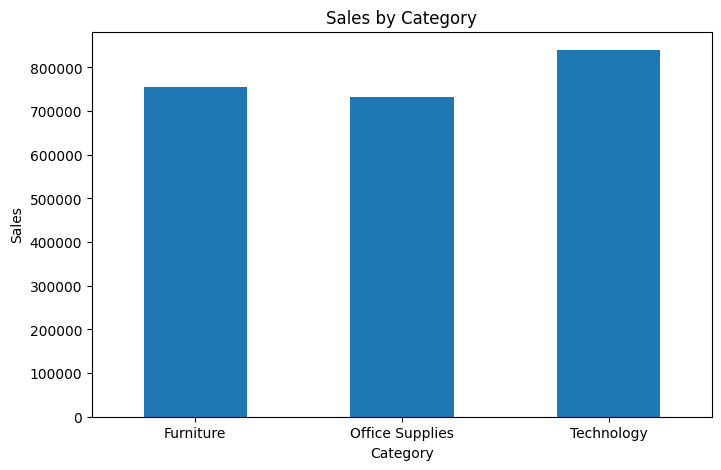

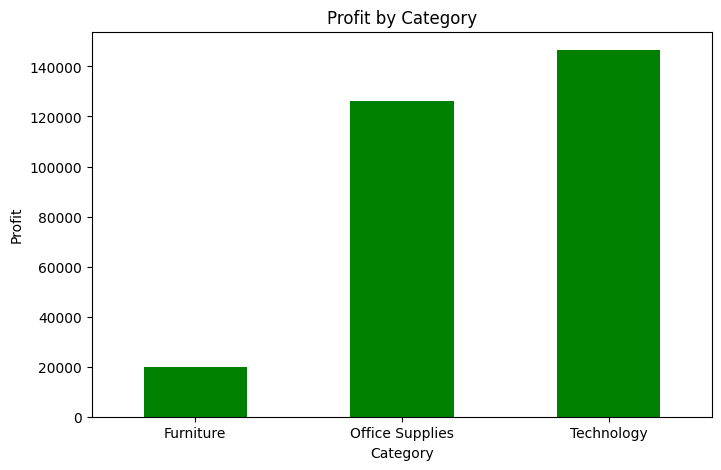

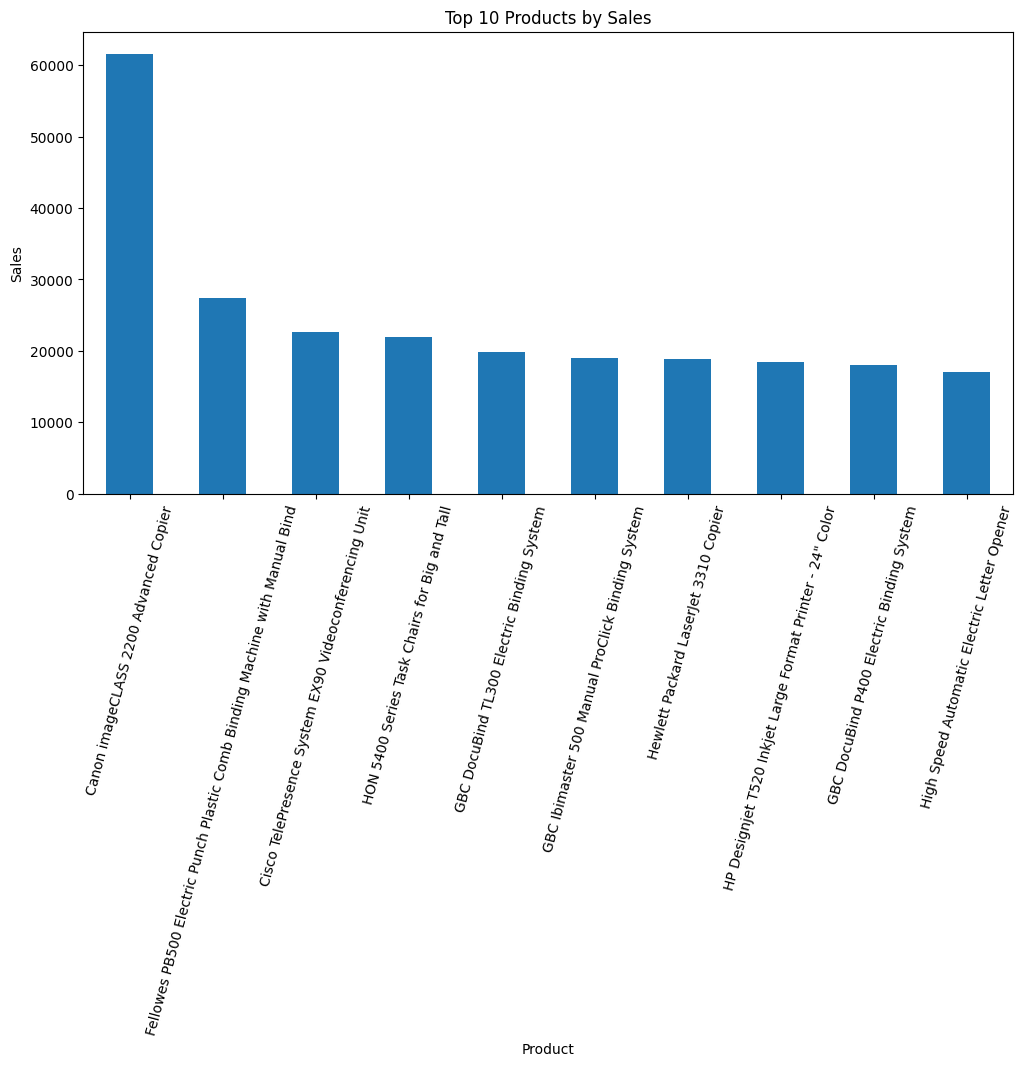

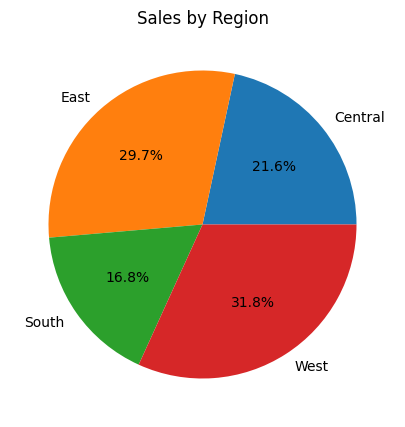

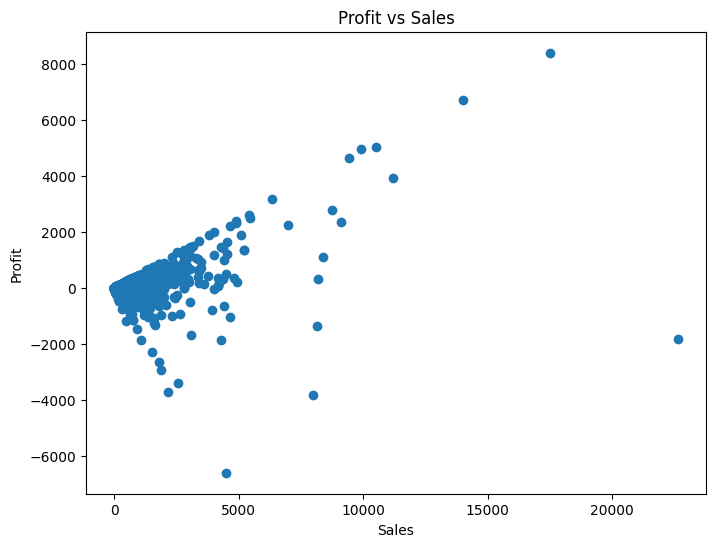

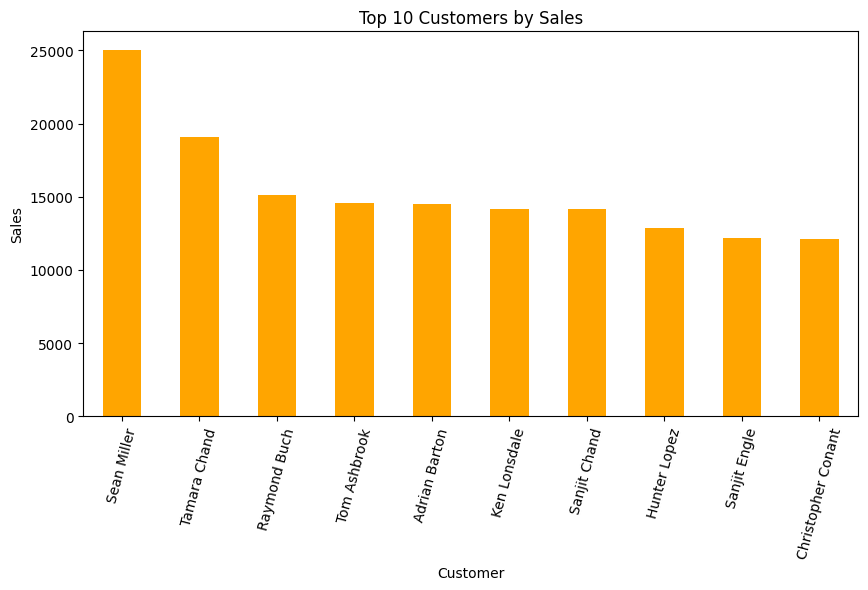


Analysis Completed Successfully!


In [3]:
# ==========================
# Sample Superstore Analysis
# Google Colab
# ==========================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Upload CSV File
from google.colab import files
uploaded = files.upload()

# Read Dataset
df = pd.read_csv(next(iter(uploaded)))

# Display First 5 Rows
print("First 5 Rows")
display(df.head())

# Dataset Information
print("\nDataset Information")
df.info()

# Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary")
display(df.describe())

# Total Sales
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

# Total Profit
total_profit = df["Profit"].sum()
print("Total Profit:", total_profit)

# ----------------------------
# Sales by Category
# ----------------------------
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

# ----------------------------
# Profit by Category
# ----------------------------
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
category_profit.plot(kind="bar", color="green")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

# ----------------------------
# Top 10 Products by Sales
# ----------------------------
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.show()

# ----------------------------
# Sales by Region
# ----------------------------
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7,5))
region_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Region")
plt.ylabel("")
plt.show()

# ----------------------------
# Profit vs Sales Scatter Plot
# ----------------------------
plt.figure(figsize=(8,6))
plt.scatter(df["Sales"], df["Profit"])
plt.title("Profit vs Sales")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

# ----------------------------
# Top 10 Customers by Sales
# ----------------------------
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar", color="orange")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.show()

print("\nAnalysis Completed Successfully!")